In [55]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
from scipy.stats import ttest_ind
from scipy.signal import find_peaks
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
%run ../functions/Transfer_longitude.ipynb
%run ../functions/Yearly_mean.ipynb
%run ../functions/Seasonal_means.ipynb
%run ../functions/Weighted_monthly_mean.ipynb
%run ../functions/mask_land_ocean.ipynb
%run ../functions/Moving_mean.ipynb
%run ../functions/lanczos_filter.ipynb

## Read the data

In [30]:
diri='/zhoulab_rit/lzhuo/data/Modelling/ense_mean_diff/Car/'
filename='Tadv.900.direct.nc'
# filename='Tadv.900.direct.nan_kept.nc'
fi=xr.open_dataset(diri+filename)
Tadv=fi.Tadv

filename='Z3_300.nc'
fi=xr.open_dataset(diri+filename)
Z3_300=fi.Z3

filename='Z3_500.nc'
fi=xr.open_dataset(diri+filename)
Z3_500=fi.Z3

filename='Z3_900.nc'
#filename='Z3_900_nan_kept.nc'
fi=xr.open_dataset(diri+filename)
Z3_900=fi.Z3

filename='TTEND_TOT_theta.900.nc'
fi=xr.open_dataset(diri+filename)
TTEND_TOT_theta=fi.TTEND_TOT_theta

In [4]:
diri='/zhoulab_rit/lzhuo/data/Modelling/'
filename='snr_Car.900.nc'
fi=xr.open_dataset(diri+filename)
snr=fi.snr

## Select the time dates

In [5]:
TTEND_TOT_theta_SD=TTEND_TOT_theta.sel(lat=slice(20,30),lon=slice(-10,30)).mean(dim=['lat','lon'])
TTEND_TOT_theta_SD_lp=lanczos_filter_xr(
    TTEND_TOT_theta_SD, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
)
TTEND_TOT_theta_SD_lp

<xarray.DataArray 'TTEND_TOT_theta' (time: 1232)>
array([nan, nan, nan, ..., nan, nan, nan])
Coordinates:
    hour_id  (time) int64 ...
  * time     (time) datetime64[ns] 1979-06-01 ... 1979-11-01T21:00:00

## Do the lanczos filter

In [31]:
Tadv_lp=lanczos_filter_xr(
    Tadv, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
)

Z3_300_lp=lanczos_filter_xr(
    Z3_300, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
)

Z3_500_lp=lanczos_filter_xr(
    Z3_500, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
)

Z3_900_lp=lanczos_filter_xr(
    Z3_900, mode="lowpass", cutoff_days=10.0, half_width_days=10.0, trim_edges=True
)

In [32]:
warm_proc = TTEND_TOT_theta_SD_lp > 0
sig = snr > 1
Z3_900_lp_all = Z3_900_lp.where(warm_proc & sig,drop=True)
Z3_500_lp_all = Z3_500_lp.where(warm_proc & sig,drop=True)
Z3_300_lp_all = Z3_300_lp.where(warm_proc & sig,drop=True)
Tadv_lp_all   = Tadv_lp.where(warm_proc & sig,drop=True)

## Plot

In [8]:
def mask_missing(var):
    frac_missing=1-var.count('time')/var.sizes['time']
    mask = frac_missing<0.5 # only retain grid points with missing value fraction smaller than 0.5
    vari=var.where(mask)
    return vari

In [58]:
def plot_phi_diff(ax,phi,intervals):
    fontsize=12
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
#     lonE=-180
#     lonW=177.5
#     latS=0
#     latN=75
    lonE=-120
    lonW=120
    latS=0
    latN=89
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res),linewidth=0.5)
    ax.set_xticks([-120,-60,0,60,120], crs=ccrs.PlateCarree())
    ax.set_yticks([0,30,60], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon

#     cmap=colorbar('WhiteBlueGreenYellowRed')
#     CF = ax.contourf(lons,lats,phi,intervals,transform=proj_data,#norm=colors.CenteredNorm(),
#                  cmap=plt.get_cmap('bwr'),extend='both')

    bounds = np.array([-2,-1.75,-1.5,-1.25,-1,-0.75,-0.5,-0.25,0.25,0.5,0.75,1,1.25,1.5,1.75,2])
    N = len(bounds) - 1
    
    # 1) 先做一个离散版 bwr（每个 bin 一个颜色）
    base = plt.cm.get_cmap("bwr", N)
    colors = base(np.arange(N))

    # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
    #    bin i 对应 [bounds[i], bounds[i+1]]
    i1 = np.where(bounds[:-1] == -0.25)[0][0]  # [-1,0]
#     i2 = np.where(bounds[:-1] ==  0)[0][0]  # [0,1]
    colors[i1] = [1, 1, 1, 1]
#     colors[i2] = [1, 1, 1, 1]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    CF = ax.contourf(lons,lats,phi,bounds,transform=proj_data,norm=norm,
                 cmap=cmap,extend='both')
    
#     cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
#     cbar.ax.tick_params(axis="x",labelsize=fontsize,pad=1)
#     color_list=['blue','blue','blue','red','red','red']
#     lines = ax.contour(lons,lats,phi_line,levels=line_intervals,colors='black', linewidths=1.5,transform=proj_data)
#     ax.clabel(lines, lines.levels,fontsize=12, fmt='%3.2f', inline=True)
#     Q = ax.quiver(lons[::4], lats[::4], u[::4,::4], v[::4,::4], color='black',units='xy',width=1,
#                   scale=0.05,scale_units='xy',transform=proj_data)
    # plot the dots using scatter
    nx, ny = np.meshgrid(phi.lon, phi.lat)
    area = np.where(phi.isnull())
    sig1 = ax.scatter(nx[area], ny[area],  s = 1, c = 'gray', transform = ccrs.PlateCarree(),alpha=0.3)
    ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

def plot_phi_diff_line(ax,phi,intervals,phi_line_500,intervals_500,phi_line_300,intervals_300):
    fontsize=12
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
#     lonE=-180
#     lonW=177.5
#     latS=0
#     latN=75
    lonE=-120
    lonW=120
    latS=0
    latN=89
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res),linewidth=0.5)
    ax.set_xticks([-120,-60,0,60,120], crs=ccrs.PlateCarree())
    ax.set_yticks([0,30,60], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon

#     cmap=colorbar('WhiteBlueGreenYellowRed')
    CF = ax.contourf(lons,lats,phi,intervals,transform=proj_data,#norm=colors.CenteredNorm(),
                 cmap=plt.get_cmap('bwr'),extend='both')
#     CF = ax.pcolormesh(lons,lats,phi,cmap=plt.get_cmap('bwr'),vmin=-20,vmax=20)
                 #cmap=plt.get_cmap('bwr')
    cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
    cbar.ax.tick_params(axis="x",labelsize=fontsize,pad=1)
    lines_500 = ax.contour(lons,lats,phi_line_500,levels=intervals_500,colors='black', linewidths=1.5,transform=proj_data)
    lines_300 = ax.contour(lons,lats,phi_line_300,levels=intervals_300,colors=[(0.0,1.0,0.0)], linewidths=1.5,transform=proj_data)
#     color_list=['blue','blue','blue','red','red','red']
#     lines = ax.contour(lons,lats,phi_line,levels=line_intervals,colors='black', linewidths=1.5,transform=proj_data)
#     ax.clabel(lines, lines.levels,fontsize=12, fmt='%3.2f', inline=True)
#     Q = ax.quiver(lons[::4], lats[::4], u[::4,::4], v[::4,::4], color='black',units='xy',width=1,
#                   scale=0.05,scale_units='xy',transform=proj_data)
    # plot the dots using scatter
    nx, ny = np.meshgrid(phi.lon, phi.lat)
    area = np.where(phi.isnull())
    sig1 = ax.scatter(nx[area], ny[area],  s = 1, c = 'gray', transform = ccrs.PlateCarree(),alpha=0.3)
    ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

In [9]:
def plot_phi_polormesh(ax,phi,intervals):
    fontsize=8
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
#     lonE=80
#     lonW=-70
#     latS=0
#     latN=70
    lonE=-120
    lonW=120
    latS=0
    latN=89
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
    ax.set_xticks([-80, -40,0,40, 80], crs=ccrs.PlateCarree())
    ax.set_yticks([0,30,60], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon
    # Specify the intervals
#     minVal = 250
#     maxVal = 350+5
#     cint = 5
#     intervals = np.arange(minVal, maxVal, cint)
#     CF = ax.contourf(lons,lats,phi,intervals,transform=proj_data,#norm=colors.CenteredNorm(),
#                  cmap=plt.get_cmap('bwr'),extend='both')
    CF = ax.pcolormesh(lons,lats,phi,cmap=plt.get_cmap('coolwarm'),vmin=-2,vmax=2)
#     cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
#     cbar.ax.tick_params(axis="x",labelsize=8,pad=1)
#     lines = ax.contour(lons,lats,phi_line,line_intervals,colors=[(0.0,1.0,0.0)],linestyles='solid', linewidths=1.5,transform=proj_data)
#     cl=ax.clabel(lines, fontsize=10, levels=np.array([1040,1060,1080,1100]),colors='k',fmt='%3.2f', inline=True,zorder=2)
#     for txt in cl:
#         txt.set_bbox(dict(
#             facecolor='white',
#             edgecolor='none',
#             alpha=0.7,   # 0.6–0.8 都很好
#             pad=0.2
#         ))
#     Q = ax.quiver(lons[::2], lats[::2], u[::2,::2], v[::2,::2], color='k',units='xy',width=0.5,
#                   scale=1.2,scale_units='xy',transform=proj_data)
#     ax.quiverkey(Q, X=0.9, Y=-0.15, U=5,   # U=1 means "1 unit" length in data
#              label="5 $m s^{-1}$", labelpos='E',fontproperties=FontProperties(size=8))
    
    nx, ny = np.meshgrid(phi.lon, phi.lat)
    area = np.where(phi.isnull())
    sig1 = ax.scatter(nx[area], ny[area],  s = 1, c = 'gray', transform = ccrs.PlateCarree())
#     ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
#     ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

In [41]:
def nan_gaussian_smooth_xr(da: xr.DataArray, sigma=0.8, truncate=3.0,
                           dims=("lat", "lon"), min_weight=0.25) -> xr.DataArray:
    """
    NaN-aware Gaussian smoothing for xarray DataArray.
    - Only smooths over `dims` (default lat/lon), keeps NaNs as NaNs.
    - Works with extra dims (e.g., time, lev) by vectorizing over them.

    sigma can be:
      - a float (same for all dims)
      - a dict like {"lat": 0.8, "lon": 1.2}
    """
    # Build sigma list in the order of da.dims
    if isinstance(sigma, dict):
        sigma_list = [sigma.get(d, 0.0) for d in da.dims]
    else:
        sigma_list = [sigma if d in dims else 0.0 for d in da.dims]

    def _smooth(arr):
        arr = arr.astype(float)
        orig_nan = ~np.isfinite(arr)          # 记住原始缺测位置
        mask = np.isfinite(arr).astype(float)
        arr0 = np.where(np.isfinite(arr), arr, 0.0)

        num = gaussian_filter(arr0, sigma=sigma_list, mode="nearest", truncate=truncate)
        den = gaussian_filter(mask, sigma=sigma_list, mode="nearest", truncate=truncate)

        out = num / np.maximum(den, 1e-12)

        # 1) 缺测边缘太“虚”的地方仍设为 NaN（可选）
        out[den < min_weight] = np.nan

        # 2) 最重要：把原来 NaN 的位置强制设回 NaN（不允许被补）
        out[orig_nan] = np.nan
        return out

    return xr.apply_ufunc(
        _smooth, da,
        input_core_dims=[list(da.dims)],
        output_core_dims=[list(da.dims)],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

Text(0.5, 1.0, '900 hPa Z3 (gpm) diff')

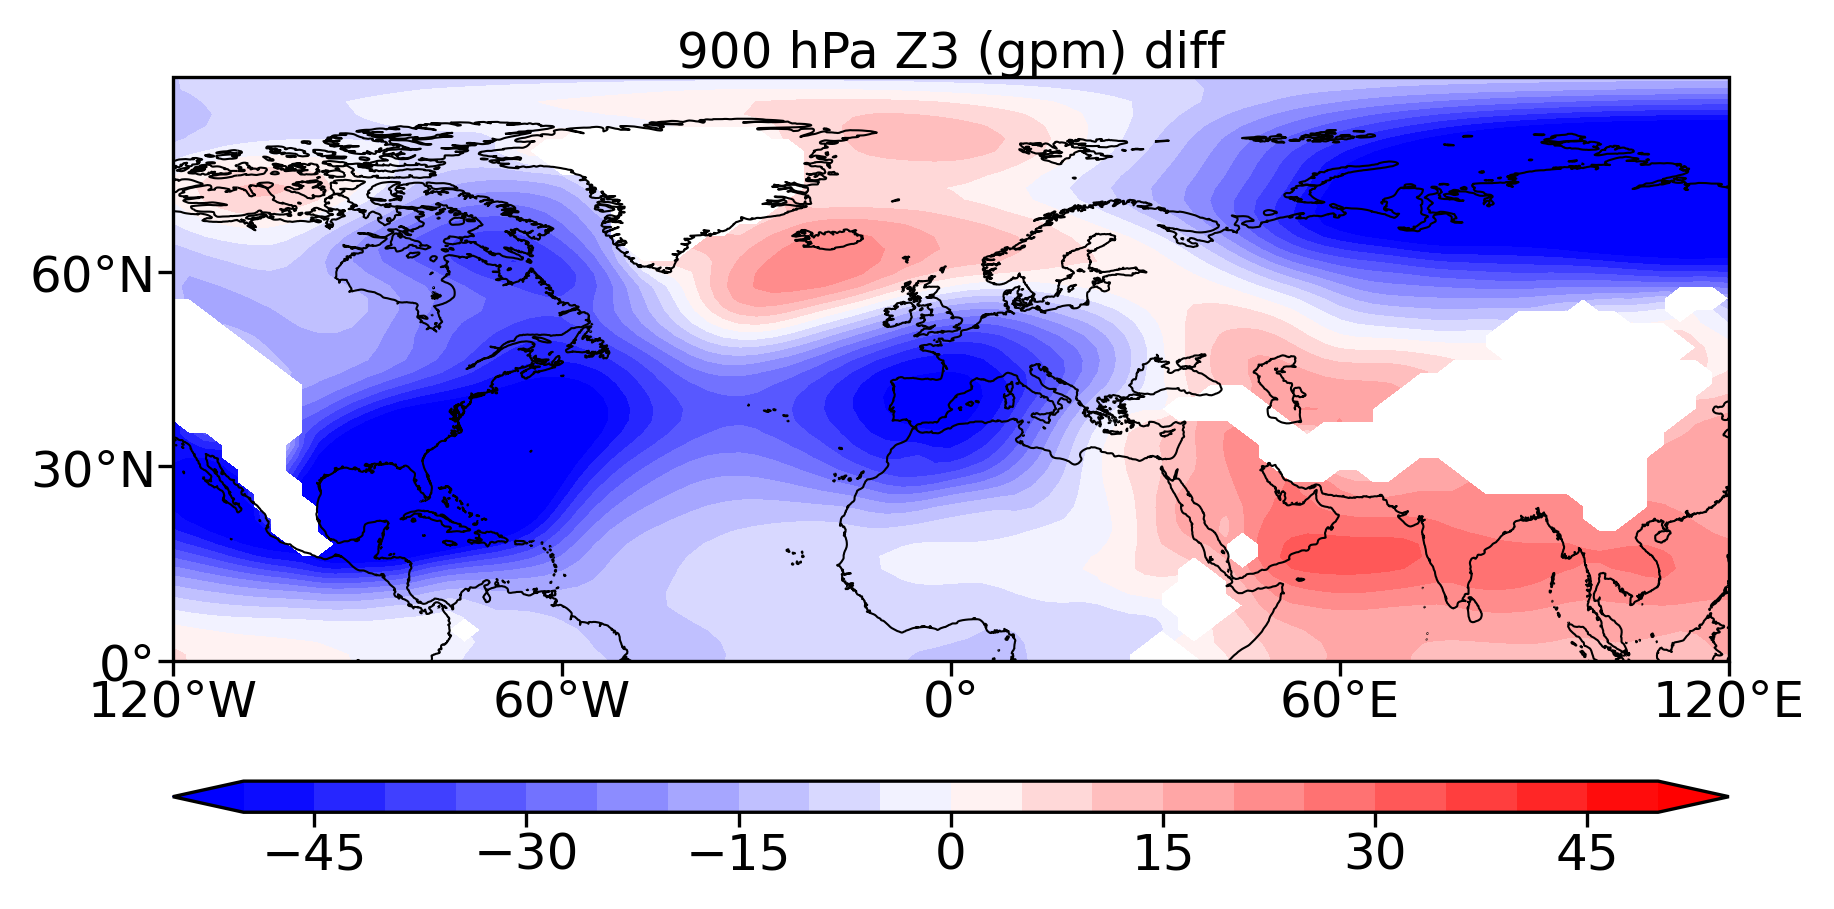

In [42]:
fig = plt.figure(figsize=(6, 4),dpi=300,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())    
minVal = -50
maxVal = 50+5
cint = 5
intervals = np.arange(minVal, maxVal, cint)
# minVal = 0
# maxVal = 5+0.5
# cint = 0.5
# intervals = np.arange(minVal, maxVal, cint)

var=Z3_900_lp_all.mean(dim='time')
var_smooth=nan_gaussian_smooth_xr(var, sigma=0.8, min_weight=0.25)
# p=ds_mc.p_mc
ax1,CF =plot_phi_diff(ax,var_smooth,intervals)
ax1.set_title('900 hPa Z3 (gpm) diff',pad=0.5)

Text(0.5, 1.0, 'Car Z3 (gpm) diff')

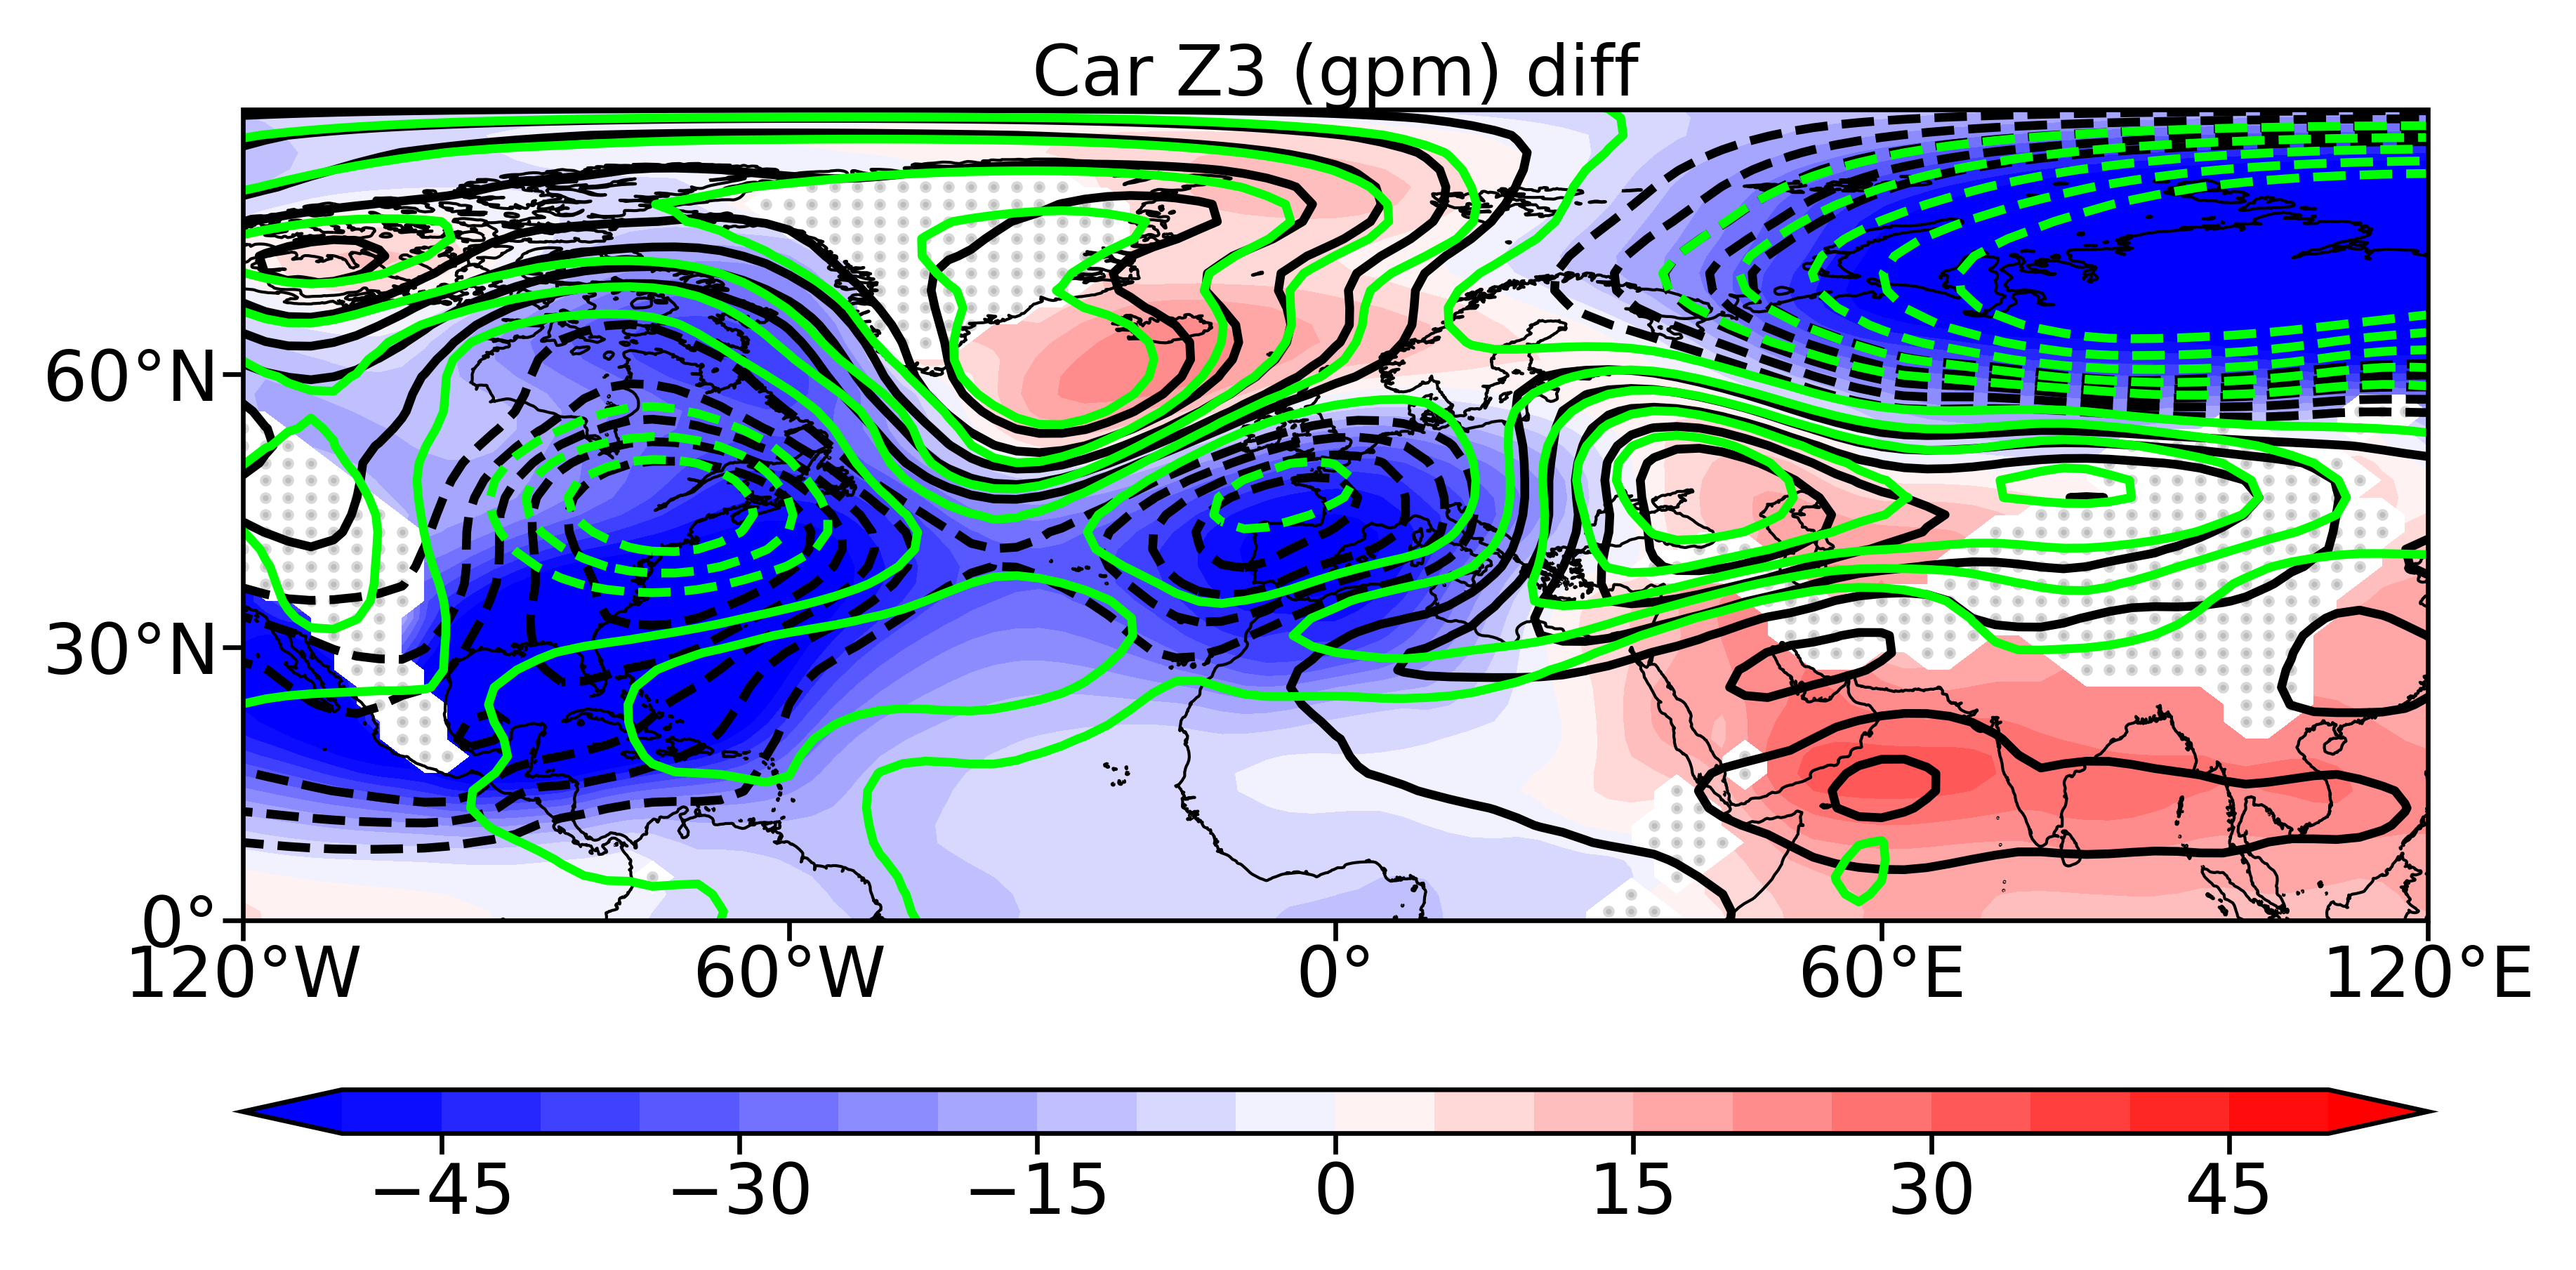

In [53]:
fig = plt.figure(figsize=(6, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())    
minVal = -50
maxVal = 50+5
cint = 5
intervals = np.arange(minVal, maxVal, cint)
# minVal = 0
# maxVal = 5+0.5
# cint = 0.5
# intervals = np.arange(minVal, maxVal, cint)

var_500=Z3_500_lp_all.mean(dim='time')
intervals_500=np.array([-50,-40,-30,-20,-10,10,20,30,40,50])

var_300=Z3_300_lp_all.mean(dim='time')
intervals_300=np.array([-100,-80,-60,-40,-20,20,40,60,80,100])

var_500_smooth=mpcalc.smooth_n_point(var_500, 9, 1)
var_300_smooth=mpcalc.smooth_n_point(var_300, 9, 1)

var=Z3_900_lp_all.mean(dim='time')
var_smooth=nan_gaussian_smooth_xr(var, sigma=0.8, min_weight=0.25)
# p=ds_mc.p_mc
ax1,CF =plot_phi_diff_line(ax,var_smooth,intervals,var_500_smooth,intervals_500,var_300_smooth,intervals_300)
ax1.set_title('Car Z3 (gpm) diff',pad=0.5)

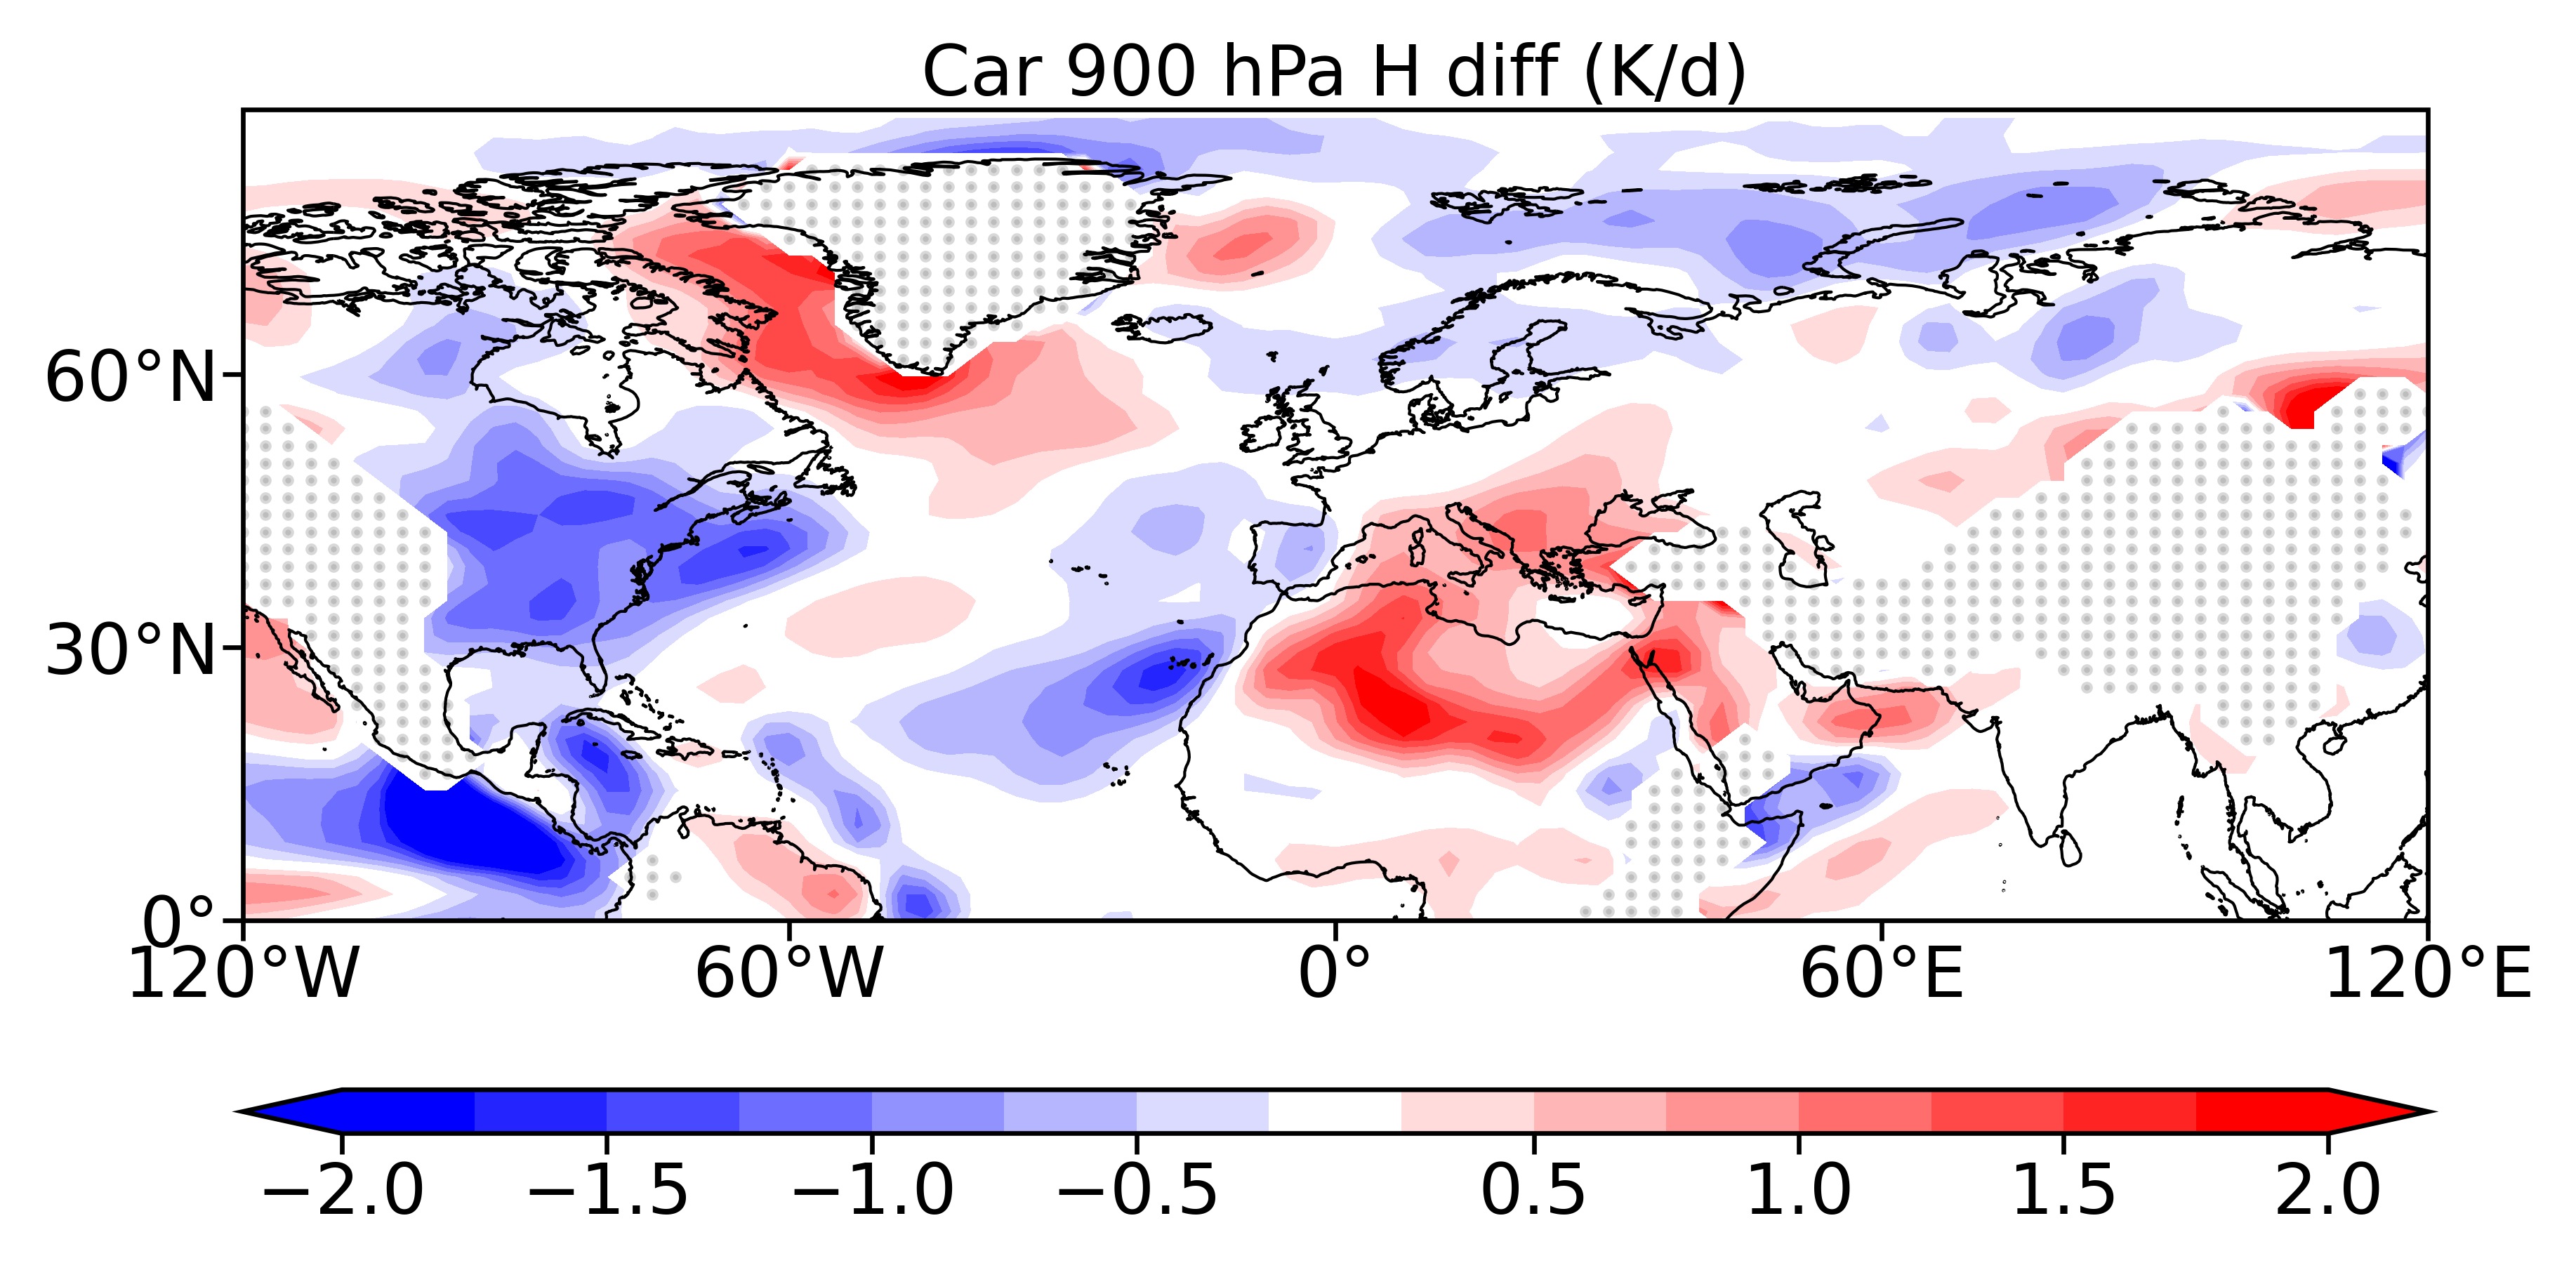

In [59]:
fig = plt.figure(figsize=(6, 4),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())    
minVal = -2
maxVal = 2+0.2
cint = 0.2
intervals = np.arange(minVal, maxVal, cint)
# minVal = 0
# maxVal = 5+0.5
# cint = 0.5
# intervals = np.arange(minVal, maxVal, cint)

var=Tadv_lp_all
# frac_missing=1-Tadv_lp_all.count('time')/Tadv_lp_all.sizes['time']
# mask = frac_missing<0.2
# vari=Tadv_lp_all.where(mask)
# frac_missing=1-v.count('time')/pot.sizes['time']
# mask = frac_missing<0.5
# v=v.where(mask)
# p=ds_mc.p_mc
# vari= mask_missing(Tadv_lp_all)
var_smooth=nan_gaussian_smooth_xr(var, sigma=0.8, min_weight=0.25)
ax1,CF =plot_phi_diff(ax,-var_smooth.mean(dim='time')*24*60*60,intervals)
ax1.set_title('Car 900 hPa H diff (K/d)',pad=0.5)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=12,pad=1)

bounds = np.array([-2,-1.5,-1,-0.5,0.5,1,1.5,2])
cbar.set_ticks(bounds)